<a href="https://colab.research.google.com/github/e23258-lgtm/Statistical-Learning-e23258/blob/main/Copy_of_Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

Assuming the standard noise distributions: the process noise $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and the measurement noise $z_k \sim \mathscr{N}(0, \Sigma_m)$, both independent of each other and the states.

1. Distribution of the Predicted State $x_k^-$Given the system equation:$$x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$$Since $x^{-}_k$ is a linear combination of two independent Gaussian random variables, $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$, it is also normally distributed:$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$Mean ($m_k^-$):Using the linearity of expectation:$$m_k^- = \mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}]$$$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$Since $\mathbb{E}[x^{+}_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:$$m_k^- = A_{k-1}m_{k-1}$$Covariance ($P_k^-$):Using the property $\text{Var}(BX + CY) = B\text{Var}(X)B^T + C\text{Var}(Y)C^T$ for independent $X$ and $Y$:$$P_k^- = \text{Var}(x^{-}_k) = \text{Var}(A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1})$$$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

2. Distribution of the Predicted Measurement $y_k^-$Given the measurement equation:$$y^{-}_k = H_k\,x^{-}_k + z_k$$Since $x^{-}_k \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, \Sigma_m)$ are independent Gaussian vectors, $y_k^-$ is normally distributed.Mean:$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k\,x^{-}_k + z_k] = H_k\mathbb{E}[x^{-}_k] + \mathbb{E}[z_k]$$$$\mathbb{E}[y^{-}_k] = H_k m_k^-$$Covariance:$$\text{Var}(y^{-}_k) = \text{Var}(H_k\,x^{-}_k + z_k) = H_k\text{Var}(x^{-}_k)H_k^T + \text{Var}(z_k)$$$$\text{Var}(y^{-}_k) = H_k P_k^- H_k^T + \Sigma_m$$Thus:$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

3. Joint Distribution of $x_k^-$ and $y^{-}_k$The joint vector $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$ is a linear transformation of Gaussian vectors, meaning it is jointly Gaussian:$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \mu_{\text{joint}}, \Sigma_{\text{joint}} \right)$$Joint Mean:$$\mu_{\text{joint}} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y^{-}_k] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$Joint Covariance Matrix:The block covariance matrix structure is:$$\Sigma_{\text{joint}} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$We already know the diagonal blocks $\text{Var}(x_k^-) = P_k^-$ and $\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$. Let's solve for the cross-covariance block:$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T\right]$$Substitute $y_k^- - H_k m_k^- = H_k(x_k^- - m_k^-) + z_k$:$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)\left(H_k(x_k^- - m_k^-) + z_k\right)^T\right]$$$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T\right]H_k^T + \mathbb{E}\left[(x_k^- - m_k^-)z_k^T\right]$$Since $x_k^-$ and $z_k$ are uncorrelated, the second term vanishes:$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$Correspondingly, $\text{Cov}(y_k^-, x_k^-) = \left(\text{Cov}(x_k^-, y_k^-)\right)^T = H_k P_k^-$.Assembling the complete joint matrix yields:$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

4.To find the conditional distribution $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$, we use the standard properties of {Gaussian Conditioning}.

Suppose we have a partitioned jointly Gaussian vector:
\[
\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix},
\begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}
\right)
\]
The conditional distribution of $(X \mid Y = y)$ is known to be Gaussian, $\mathscr{N}(m, P)$, with parameters defined as:
\begin{align*}
m &= \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y) \\
P &= \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}
\end{align*}

\noindent Mapping our joint distribution blocks from the result in Question 3 to this formula, we identify:
\begin{align*}
X &\rightarrow x_k^-, \quad Y \rightarrow y_k^-, \quad y \rightarrow y^{\mathrm{obs}}_{k} \\
\mu_X &= m_k^- \\
\mu_Y &= H_k m_k^- \\
\Sigma_{XX} &= P_k^- \\
\Sigma_{XY} &= P_k^- H_k^T \\
\Sigma_{YY} &= H_k P_k^- H_k^T + \Sigma_m \\
\Sigma_{YX} &= H_k P_k^-
\end{align*}

We define the Kalman gain matrix $$K_k \triangleq \Sigma_{XY}\Sigma_{YY}^{-1}$$. Substituting our specific block definitions yields:
$$[
K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}
]$$

Substituting the identified parameters into the conditional mean formula:
\begin{align*}
m_k &= \mu_X + K_k (y^{\mathrm{obs}}_{k} - \mu_Y) \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)
\end{align*}

Substituting the identified parameters into the conditional covariance formula:
\begin{align*}
P_k &= \Sigma_{XX} - K_k \Sigma_{YX} \\
P_k &= P_k^- - K_k (H_k P_k^-)
\end{align*}
Factoring out $P_k^-$ from the right-hand side expressions gives:
$$[
P_k = (I - K_k H_k) P_k^-
]$$

\noindent Therefore, it is proven that $x^{+}_k \sim \mathscr{N}(m_k, P_k)$ with the required forms.

5.Therefore, given $y^{-}_k = y^{\mathrm{obs}}_{k}$:Conditional Expectation:$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$Conditional Variance:$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

1. Given the scalar state transition equation:$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$where $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0,q)$ are independent.

Mean ($m_k^-$):Taking the expectation on both sides:$$m_k^- = \mathbb{E}[x^-_k] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1}]$$By the linearity of expectation and noting that $\mathbb{E}[w_{k-1}] = 0$:$$m_k^- = a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}] = a\,m_{k-1}$$Variance ($P_k^-$):Taking the variance on both sides:$$P_k^- = \text{Var}(x^-_k) = \text{Var}(a\,x^+_{k-1} + w_{k-1})$$Since $x^+_{k-1}$ and $w_{k-1}$ are independent, the variance of their sum is the sum of their variances:$$P_k^- = a^2\text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$

2. Updated State Statistics ($m_k$ and $P_k$)We construct the joint distribution of $x^-_k$ and $y^-_k$. From the measurement equation $y^-_k = h\,x^-_k + z_k$, the joint distribution is Gaussian:$$\begin{bmatrix} x^-_k \\ y^-_k \end{bmatrix} \sim \mathscr{N} \left( \begin{bmatrix} m_k^- \\ h\,m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & hP_k^- \\ hP_k^- & h^2 P_k^- + r \end{bmatrix} \right)$$Let the measurement residual variance be $S_k = h^2 P_k^- + r$. Using Gaussian conditioning rules for $p(x^-_k \mid y^-_k = y^{\mathrm{obs}}_k)$, the Kalman gain $K_k$ is:$$K_k = \frac{\text{Cov}(x^-_k, y^-_k)}{\text{Var}(y^-_k)} = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$$Updated Mean ($m_k$):$$m_k = m_k^- + K_k(y^{\mathrm{obs}}_k - h\,m_k^-) = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$Updated Variance ($P_k$):$$P_k = P_k^- - K_k \cdot \text{Cov}(y^-_k, x^-_k) = P_k^- - K_k (hP_k^-) = (1 - K_k h)P_k^-$$Substituting $K_k$:$$P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

3. Predictive Measurement Distribution ($p(y^-_k \mid Y_{k-1})$)Before the measurement $y^{\mathrm{obs}}_k$ is received at step $k$, our knowledge of the state is characterized by $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$.Substituting this into the measurement model $y^-_k = h\,x^-_k + z_k$:Mean:$$\mathbb{E}[y^-_k \mid Y_{k-1}] = \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$$Variance:$$\text{Var}(y^-_k \mid Y_{k-1}) = \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) = h^2\text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$Thus:$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

4. Post-Filtering Measurement Distribution ($p(y^-_k \mid Y_k)$)After filtering on the observed data up to step $k$, the state profile is updated to $x_k \mid Y_k \sim \mathscr{N}(m_k, P_k)$. If we look at the distribution of the underlying true measurement variable $y^-_k = h\,x_k + z_k$ conditional on this state updates:Mean:$$\mathbb{E}[y^-_k \mid Y_k] = \mathbb{E}[h\,x_k + z_k \mid Y_k] = h\,m_k$$Variance:$$\text{Var}(y^-_k \mid Y_k) = \text{Var}(h\,x_k + z_k \mid Y_k) = h^2 P_k + r$$Thus:$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

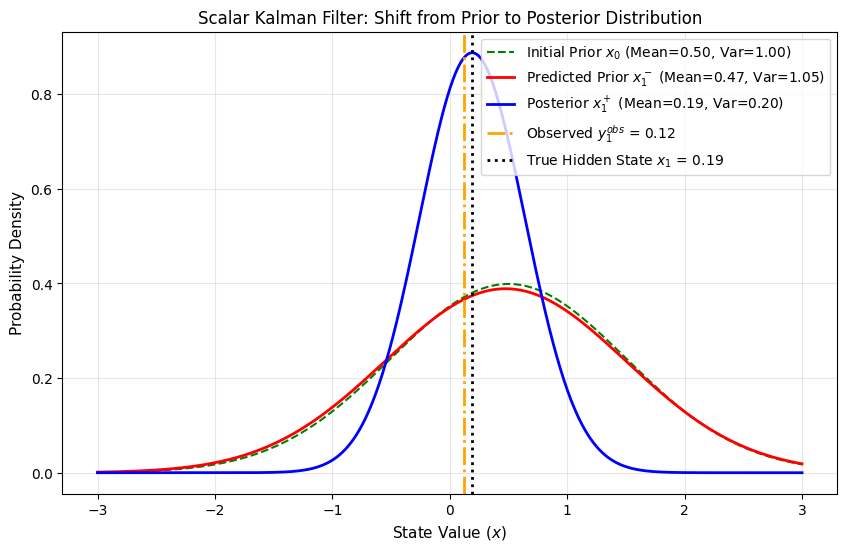

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
np.random.seed(42)
a = 0.95   # State transition scalar
q = 0.15   # Process noise variance
h = 1.0    # Measurement scalar
r = 0.25   # Measurement noise variance

# True Initializations
x_true = 0.0
m_0 = 0.5
P_0 = 1.0

# Storage for plotting a single step breakdown
m_k_minus = a * m_0
P_k_minus = a**2 * P_0 + q

# Simulate a true state trajectory and observation for step 1
x_true_1 = a * x_true + np.random.normal(0, np.sqrt(q))
y_obs_1 = h * x_true_1 + np.random.normal(0, np.sqrt(r))

# Calculate update (Posterior) at step 1
S_1 = h**2 * P_k_minus + r
K_1 = (P_k_minus * h) / S_1
m_1 = m_k_minus + K_1 * (y_obs_1 - h * m_k_minus)
P_1 = (1 - K_1 * h) * P_k_minus

# Plotting the distributions
x_axis = np.linspace(-3, 3, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, norm.pdf(x_axis, m_0, np.sqrt(P_0)), 'g--', label=f'Initial Prior $x_0$ (Mean={m_0:.2f}, Var={P_0:.2f})', linewidth=1.5)
plt.plot(x_axis, norm.pdf(x_axis, m_k_minus, np.sqrt(P_k_minus)), 'r-', label=f'Predicted Prior $x_1^-$ (Mean={m_k_minus:.2f}, Var={P_k_minus:.2f})', linewidth=2)
plt.plot(x_axis, norm.pdf(x_axis, m_1, np.sqrt(P_1)), 'b-', label=f'Posterior $x_1^+$ (Mean={m_1:.2f}, Var={P_1:.2f})', linewidth=2)
plt.axvline(x=y_obs_1, color='orange', linestyle='-.', label=f'Observed $y_1^{{obs}}$ = {y_obs_1:.2f}', linewidth=2)
plt.axvline(x=x_true_1, color='black', linestyle=':', label=f'True Hidden State $x_1$ = {x_true_1:.2f}', linewidth=2)

plt.title('Scalar Kalman Filter: Shift from Prior to Posterior Distribution', fontsize=12)
plt.xlabel('State Value ($x$)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

 Under a two-dimensional constant-velocity assumption, the physics of motion over a discrete time step $\Delta t$ can be modeled using Newtonian kinematics. Let the process noise vector at time step $k-1$ represent the random acceleration perturbations: $w_{k-1} = \left[ \begin{smallmatrix} a_x(k-1) \\ a_y(k-1) \end{smallmatrix} \right]$.

The kinematic equations governing the positions and velocities from time step $k-1$ to step $k$ are:
\newline
$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \textstyle \frac{1}{2}a_x(k-1)\Delta t^2$

$p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \textstyle \frac{1}{2}a_y(k-1)\Delta t^2$

$v_x(k) = v_x(k-1) + a_x(k-1)\Delta t$

$v_y(k) = v_y(k-1) + a_y(k-1)\Delta t$

 We express this system of linear equations in matrix form matching the state transition model $x^-_k = A x^+_{k-1} + G w_{k-1}$ using standard text-sized dimensions:

$\left[ \begin{smallmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{smallmatrix} \right] = \left[ \begin{smallmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{smallmatrix} \right] \left[ \begin{smallmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{smallmatrix} \right] + \left[ \begin{smallmatrix} \textstyle \frac{1}{2}\Delta t^2 & 0 \\ 0 & \textstyle \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{smallmatrix} \right] \left[ \begin{smallmatrix} a_x(k-1) \\ a_y(k-1) \end{smallmatrix} \right]$

 By direct inspection, matching this with the filter definition explicitly confirms the structures of $A$ and $G$:
\newline
$A = \left[ \begin{smallmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{smallmatrix} \right]$,  $G = \left[ \begin{smallmatrix} \textstyle \frac{1}{2}\Delta t^2 & 0 \\ 0 & \textstyle \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{smallmatrix} \right]$

The system records only the noisy position parameters. Thus, the measurement equations for $y_k = H x_k + z_k$ translate explicitly into:

$p_x^{\mathrm{meas}}(k) = 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_x(k)$

$p_y^{\mathrm{meas}}(k) = 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_y(k)$

 Grouping these equations into vector-matrix notation gives:

$\left[ \begin{smallmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{smallmatrix} \right] = \left[ \begin{smallmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{smallmatrix} \right] \left[ \begin{smallmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{smallmatrix} \right] + \left[ \begin{smallmatrix} z_x(k) \\ z_y(k) \end{smallmatrix} \right]$

 Matching this system setup with the linear filter model yields the measurement projection matrix:

$H = \left[ \begin{smallmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{smallmatrix} \right]$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

In [2]:
import numpy as np

class LinearKalmanFilter2D:
    """
    A 2D Constant-Velocity Kalman Filter for tracking position (px, py)
    and velocity (vx, vy) from noisy position measurements.
    """
    def __init__(self, dt: float, q_std: float, r_std: float):
        """
        Parameters:
        -----------
        dt    : Time step interval (seconds).
        q_std : Process noise standard deviation (acceleration uncertainty).
        r_std : Measurement noise standard deviation (GPS position uncertainty).
        """
        self.dt = dt

        # 1. State vector [px, py, vx, vy]^T initialized to zeros
        self.x = np.zeros((4, 1))

        # 2. State Covariance Matrix P (Initial high uncertainty)
        self.P = np.eye(4) * 100.0

        # 3. State Transition Matrix A
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # 4. Process Noise Matrix G and Covariance Sigma_p
        G = np.array([
            [0.5 * (dt**2), 0],
            [0, 0.5 * (dt**2)],
            [dt, 0],
            [0, dt]
        ])
        # Assuming independent x and y acceleration variances
        Sigma_p = np.eye(2) * (q_std ** 2)
        self.Q = G @ Sigma_p @ G.T

        # 5. Measurement Matrix H (extracts px and py)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # 6. Measurement Noise Covariance Matrix Sigma_m (R)
        self.R = np.eye(2) * (r_std ** 2)

    def initialize_state(self, init_x: float, init_y: float):
        """Initializes the filter with the first known GPS coordinate."""
        self.x[0, 0] = init_x
        self.x[1, 0] = init_y
        self.P = np.eye(4) * 1.0  # Reduce uncertainty upon initialization

    def predict(self):
        """Step 1: Predict the next state and covariance ahead (Time Update)"""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x

    def update(self, z: np.ndarray):
        """Step 2: Correct the predictions using a new GPS measurement (Measurement Update)"""
        # Ensure z is a column vector [[meas_x], [meas_y]]
        z = z.reshape(2, 1)

        # Innovation (Residual)
        y = z - (self.H @ self.x)

        # Innovation Covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman Gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Update State and Covariance
        self.x = self.x + (K @ y)
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x

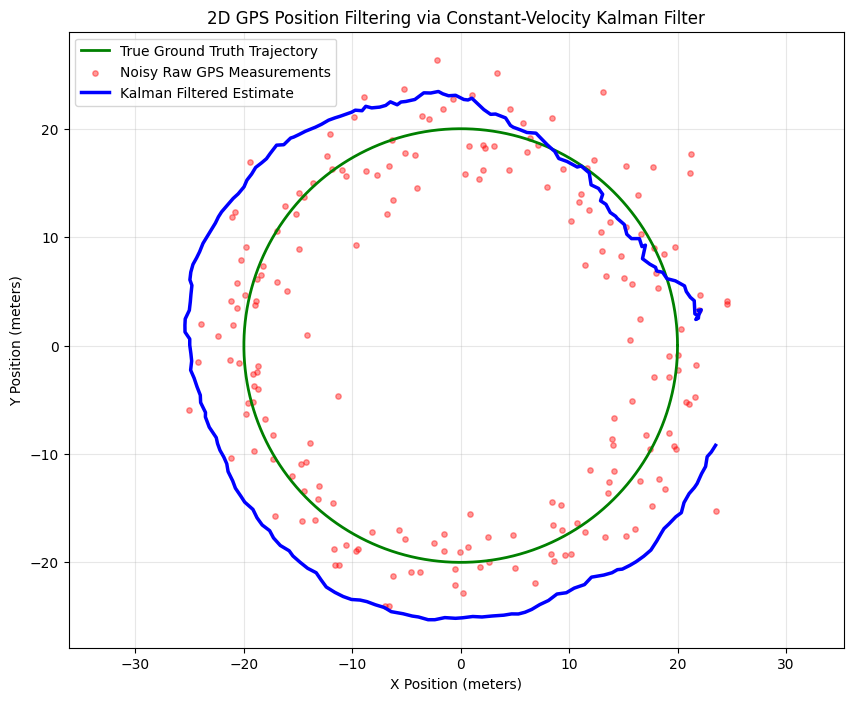

In [3]:
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
dt = 0.1         # 10 Hz sampling rate
num_steps = 200
q_std = 0.5      # Physical acceleration drift
r_std = 3.0      # GPS noise radius error (in meters)

# Generate true trajectory (moving in a circle)
t = np.linspace(0, 2 * np.pi, num_steps)
true_px = 20 * np.cos(t)
true_py = 20 * np.sin(t)

# Add Gaussian noise to create simulated GPS observations
noisy_px = true_px + np.random.normal(0, r_std, num_steps)
noisy_py = true_py + np.random.normal(0, r_std, num_steps)

# --- Apply the Kalman Filter ---
kf = LinearKalmanFilter2D(dt=dt, q_std=q_std, r_std=r_std)
kf.initialize_state(noisy_px[0], noisy_py[0])

filtered_states = []

for i in range(num_steps):
    # 1. Predict state forward
    kf.predict()

    # 2. Update with the noisy GPS coordinate
    measurement = np.array([noisy_px[i], noisy_py[i]])
    current_state = kf.update(measurement)

    # Store the result [px, py, vx, vy]
    filtered_states.append(current_state.flatten())

filtered_states = np.array(filtered_states)

# --- Visualization ---
plt.figure(figsize=(10, 8))
plt.plot(true_px, true_py, 'g-', label='True Ground Truth Trajectory', linewidth=2)
plt.scatter(noisy_px, noisy_py, color='red', alpha=0.4, s=15, label='Noisy Raw GPS Measurements')
plt.plot(filtered_states[:, 0], filtered_states[:, 1], 'b-', label='Kalman Filtered Estimate', linewidth=2.5)

plt.title('2D GPS Position Filtering via Constant-Velocity Kalman Filter')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()